In [1]:
print("Hello")

Hello


In [2]:
%load_ext autoreload
%autoreload 2

In [9]:
from backend.app.services.data_services import fetch_data_to_df

In [7]:
from backend.app.services.data_services import (
    get_available_indicators,
    get_available_strategies,
    get_strategies_metadata,
    get_available_tickers,
    _read_csv,
    fetch_data_to_df,
    get_indicators_metadata,
    _load_and_resample_data
)
import importlib
import backend.app.core.Strategies as st

import backend.app.services.cache_service as cs
import backend.app.services.data_services as ds
import backend.app.services.plotting_services as ps
import backend.app.services.backtest_services as bs

# importlib.reload(cs)
# importlib.reload(ds)
# importlib.reload(ps)
# importlib.reload(bs)

import asyncio
import pandas as pd
import numpy as np
import vectorbt as vbt

In [10]:
ticker_name = "TATA CONSULTANCY SERVICES"
df = await ds._read_csv(ticker_name=ticker_name)
await cs.set_data(df=df, ticker= ticker_name)

{'message': 'Data loaded successfully with key: data:TATA CONSULTANCY SERVICES'}

In [11]:
cs.get_key_list()
# await cs.delete_data("SOLUSD")
# ds.get_available_tickers()
# ds.get_available_strategies()

['data:RELIANCE INDUSTRIES LTD', 'data:TATA CONSULTANCY SERVICES']

In [12]:
df = await ds.fetch_data_to_df("TATA CONSULTANCY SERVICES",start_date= '01/12/2024 09:15:00', end_date='30/12/2024 09:15:00', interval='15m')
df

d:\OneDrive - iitgn.ac.in\Desktop\HedgeOne-Quant\backend\app\services\data_services.py:54: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



{'data': [{'open': '4270.0',
   'high': '4270.0',
   'low': '4230.05',
   'close': '4242.25',
   'volume': '173535'},
  {'open': '4242.25',
   'high': '4257.95',
   'low': '4232.65',
   'close': '4256.4',
   'volume': '77131'},
  {'open': '4257.45',
   'high': '4278.55',
   'low': '4256.5',
   'close': '4264.3',
   'volume': '55148'},
  {'open': '4263.25',
   'high': '4263.85',
   'low': '4248.7',
   'close': '4256.85',
   'volume': '41959'},
  {'open': '4257.75',
   'high': '4271.9',
   'low': '4254.3',
   'close': '4259.9',
   'volume': '58076'},
  {'open': '4260.0',
   'high': '4260.75',
   'low': '4251.35',
   'close': '4256.15',
   'volume': '34566'},
  {'open': '4256.1',
   'high': '4259.5',
   'low': '4250.95',
   'close': '4255.05',
   'volume': '34782'},
  {'open': '4255.15',
   'high': '4262.0',
   'low': '4253.5',
   'close': '4255.5',
   'volume': '23780'},
  {'open': '4255.5',
   'high': '4265.6',
   'low': '4255.0',
   'close': '4259.1',
   'volume': '32053'},
  {'open': 

In [92]:
resolution = "1h"
start_date = "01/10/2022 09:15:00"
end_date = "01/10/2025 09:15:00"

df = await ds._load_and_resample_data(ticker_name, resolution, start_date, end_date)
print(df.shape)
df.head()

(5185, 5)


d:\OneDrive - iitgn.ac.in\Desktop\HedgeOne-Quant\backend\app\services\data_services.py:54: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



,open,high,low,close,volume
2022-10-03 09:00:00,1195.75,1208.47,1185.97,1193.35,3145810
2022-10-03 10:00:00,1193.28,1195.00,1188.05,1189.00,1556464
2022-10-03 11:00:00,1189.08,1198.20,1187.60,1192.60,1166418
2022-10-03 12:00:00,1192.65,1193.70,1187.53,1189.58,846956
2022-10-03 13:00:00,1189.25,1194.50,1186.10,1187.03,811054


In [94]:
price = df['close']

# ------------------------------------------------------------
# 2. Build EMA indicators (9 & 26)
# ------------------------------------------------------------
ema_fast = vbt.MA.run(price, window=9)
ema_slow = vbt.MA.run(price, window=26)

# rsi = v

# ------------------------------------------------------------
# 3. Define Entry/Exit Signals
# ------------------------------------------------------------
entries1 = ema_fast.ma_crossed_above(ema_slow)
exits   = ema_fast.ma_crossed_below(ema_slow)

entries2 = vbt.RSI.run(price, window=7).rsi < 20
# exits2 = vbt.RSI.run(price, window=14).rsi > 70

entries = entries1 & entries2

# ------------------------------------------------------------
# 4. Run Backtest
# ------------------------------------------------------------
p = vbt.Portfolio.from_signals(
    close=price,
    entries=entries,
    exits=exits,
    init_cash=100000,
    fees=0.0,
    slippage=0.0,
    freq='1h'
)

In [95]:
p.total_return()

0.013829839235645194

In [96]:
p.stats()

Start                         2022-10-03 09:00:00
End                           2025-10-01 09:00:00
Period                          216 days 01:00:00
Start Value                              100000.0
End Value                           101382.983924
Total Return [%]                         1.382984
Benchmark Return [%]                    14.710688
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                         1.208469
Max Drawdown Duration           135 days 01:00:00
Total Trades                                    2
Total Closed Trades                             2
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                                100.0
Best Trade [%]                           1.227386
Worst Trade [%]                          0.153711
Avg Winning Trade [%]                    0.690549
Avg Losing Trade [%]                          NaN


In [ ]:
p.plot()

FigureWidget({
    'data': [{'legendgroup': '0',
              'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': '8d9dba23-6861-4009-a616-120f7c254eec',
              'x': array(['2022-10-03T09:00:00.000000000', '2022-10-03T10:00:00.000000000',
                          '2022-10-03T11:00:00.000000000', ..., '2025-09-30T14:00:00.000000000',
                          '2025-09-30T15:00:00.000000000', '2025-10-01T09:00:00.000000000'],
                         dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': ('ZmZmZmalkkAAAAAAAJSSQGZmZmZmop' ... 'zMzFKVQAAAAAAAUJVAmpmZmZljlUA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'customdata': {'bdata': 'AAAAAAAAAAApYQe94ZtVQAAAAAAAAAAAAAAAAAAAAED3vXEOBoZSQAAAAAAAAAAA',
                             'dtype': 'f8',
                             'shape': '2, 3'},
              'hovertemp

In [98]:
# strategy_name = "EMA Crossover"
# params = {"short_window": 9, "long_window": 26}

strategy_name = "RSI"
params = {"overbought": 70, "oversold": 30, "window":7}

initial_cash = 100000
fees = 0.0
slippage = 0

backtest_result = await bs.run_full_backtest(
    ticker_name=ticker_name,
    start_date=start_date,
    end_date=end_date,
    interval=resolution,
    strategy_name=strategy_name,
    params=params,
    initial_cash=initial_cash,
    fees=fees,
    slippage=slippage,
    df = df
)

[BACKTEST] Starting
[DATA] Loading
[STRATEGY] Running
[TIME SLICE] Running
[BACKTEST] Completed


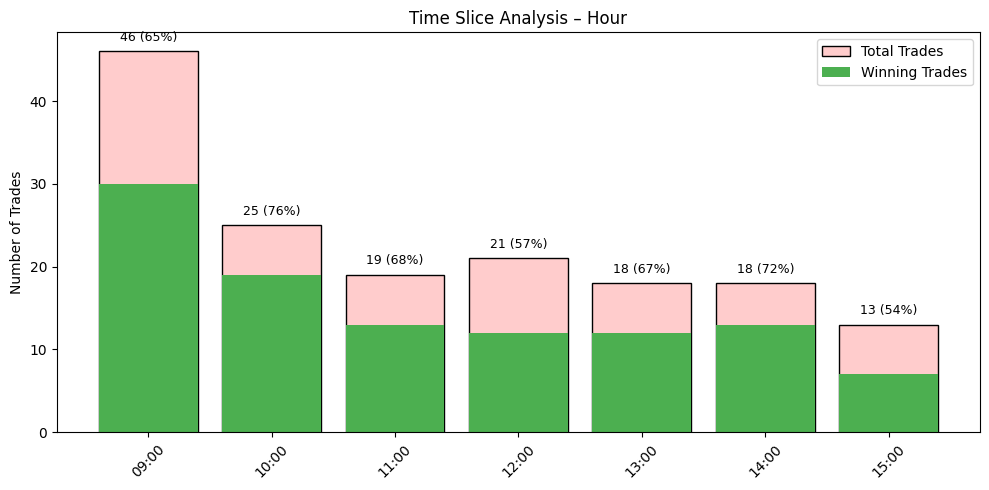

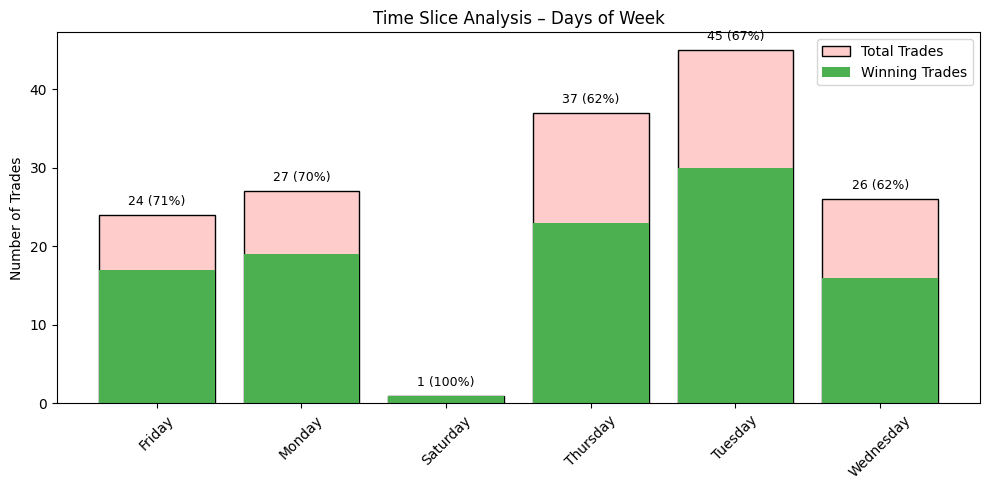

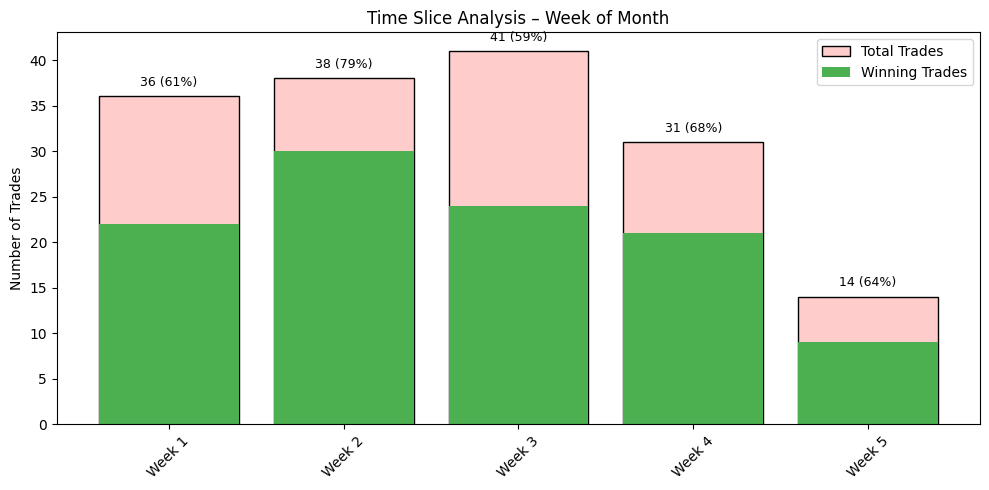

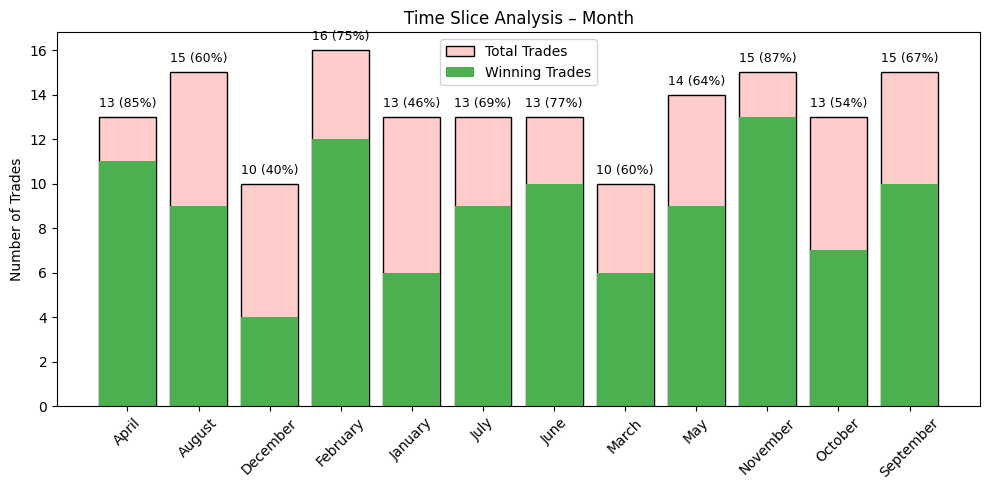

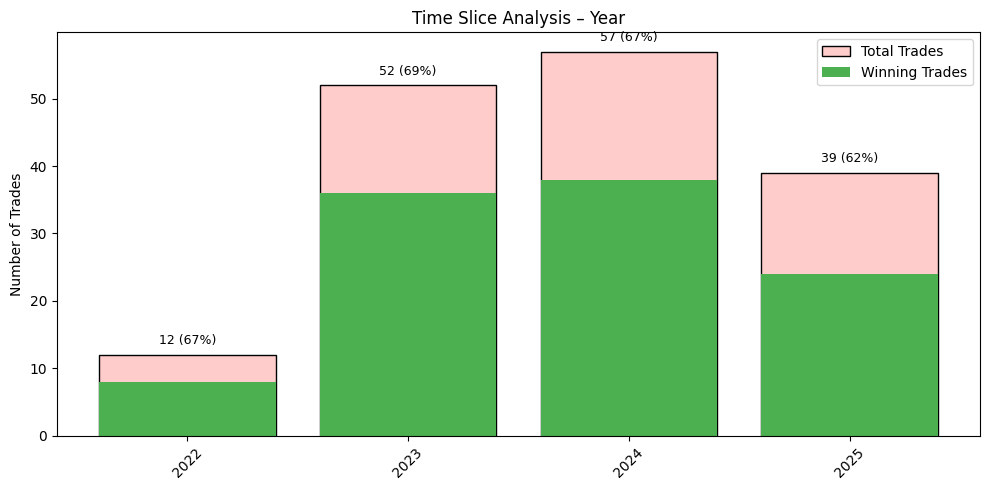

In [99]:
# for k, v in backtest_result["backtest_result"].items():
#     print(f"{k}: {v}")

# for unit, data in backtest_result["time_slice_analysis"].items():
#     print(f"{unit}: {data}")

plotter = ps.TimeSlicePlotter(backtest_result["time_slice_analysis"])
plotter.plot()
# plotter.plot_trades("Days of Week")
# plotter.plot_total_return("Days of Week")
# plotter.days()
# plotter.weeks()
# plotter.months()

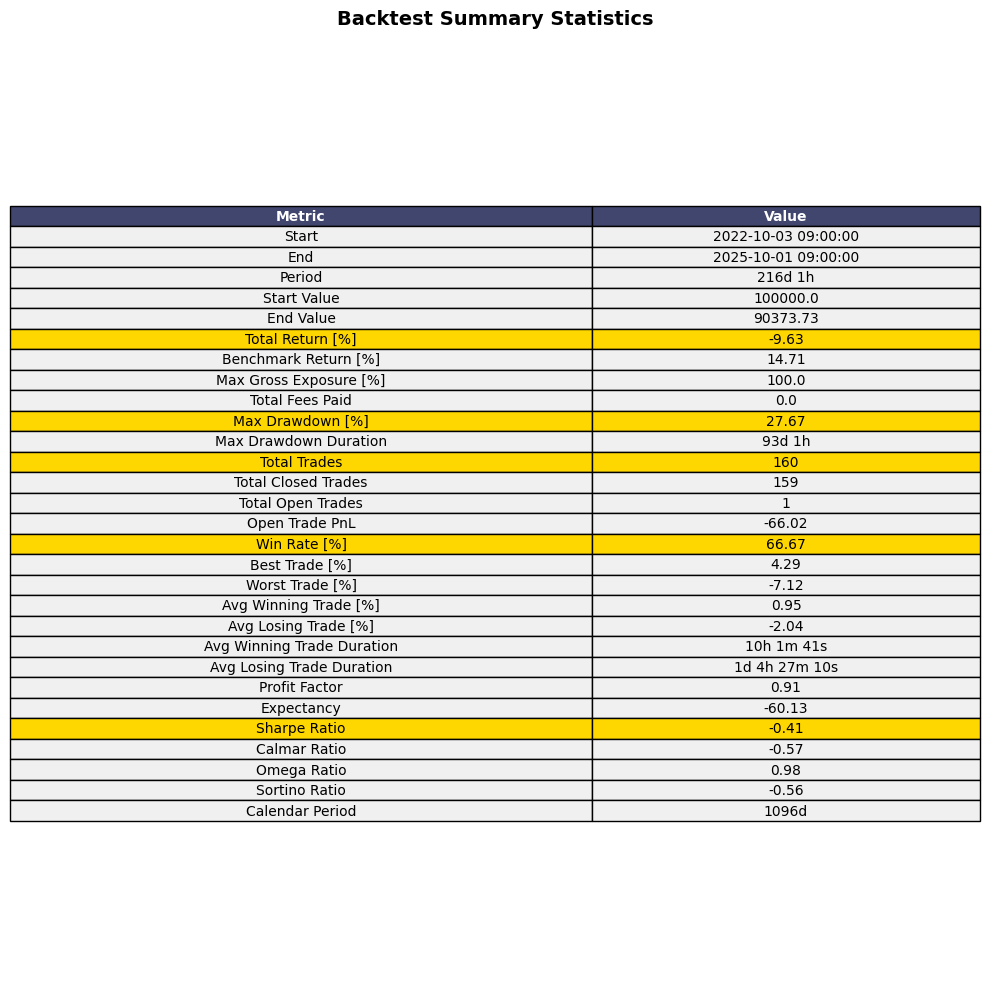

In [100]:
stats = backtest_result["backtest_result"]
visualizer = ps.BacktestStatsVisualizer(stats)
visualizer.plot_table()

In [ ]:
prices = df['close']

ema_fast = vbt.MA.run(prices, 9)
ema_slow = vbt.MA.run(prices, np.arange(25,36))

entries = ema_fast.ma_crossed_above(ema_slow)
exits   = ema_fast.ma_crossed_below(ema_slow)

pf = vbt.Portfolio.from_signals(
    close=prices,
    entries=entries,
    exits=exits,
    init_cash=10000,
    fees=0.0005,
    slippage=0.0,
    freq='30min'
)

In [ ]:
pd.DataFrame(pf.annualized_return()).shape

In [ ]:
pf.stats()

C:\Users\Asus\AppData\Local\Temp\ipykernel_11324\3705677322.py:1: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x000001B25AF157E0>. Pass column to select a single column/group.



Start                               2024-12-02 09:15:00
End                                 2025-10-01 09:15:00
Period                                108 days 08:30:00
Start Value                                     10000.0
End Value                                   6204.165292
Total Return [%]                             -37.958347
Benchmark Return [%]                           7.045668
Max Gross Exposure [%]                            100.0
Total Fees Paid                             3473.056712
Max Drawdown [%]                              38.357121
Max Drawdown Duration                 107 days 12:22:30
Total Trades                                     441.25
Total Closed Trades                              440.75
Total Open Trades                                   0.5
Open Trade PnL                                -1.412349
Win Rate [%]                                  26.030808
Best Trade [%]                                 4.145289
Worst Trade [%]                               -4

: 